In [1]:
import os
import getpass
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector


In [2]:

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="RestaurantDB"
)

print("Database Connected Successfully!")

Database Connected Successfully!


In [3]:
customers = pd.read_sql("SELECT * FROM Customers", connection)
employees = pd.read_sql("SELECT * FROM Employees", connection)
menu = pd.read_sql("SELECT * FROM MenuItems", connection)
orders = pd.read_sql("SELECT * FROM Orders", connection)
order_details = pd.read_sql("SELECT * FROM OrderDetails", connection)
payments = pd.read_sql("SELECT * FROM Payments", connection)
categories = pd.read_sql("SELECT * FROM Categories", connection)
tables = pd.read_sql("SELECT * FROM RestaurantTables", connection)

C:\Users\ishit\AppData\Local\Temp\ipykernel_26068\2254827293.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM Customers", connection)
C:\Users\ishit\AppData\Local\Temp\ipykernel_26068\2254827293.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  employees = pd.read_sql("SELECT * FROM Employees", connection)
C:\Users\ishit\AppData\Local\Temp\ipykernel_26068\2254827293.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  menu = pd.read_sql("SELECT * FROM MenuItems", connection)
C:\Use

In [4]:
print(customers.head())
print(employees.head())
print(menu.head())
print(orders.head())
print(payments.head())

   CustomerID   CustomerName       Phone             Email
0           1   Aarav Sharma  9876543210   aarav@gmail.com
1           2  Ishita Tiwari  9876543211  ishita@gmail.com
2           3    Rohan Singh  9876543212   rohan@gmail.com
3           4    Priya Gupta  9876543213   priya@gmail.com
4           5    Karan Mehta  9876543214   karan@gmail.com
   EmployeeID  EmployeeName     Role   Salary
0           1  Rahul Sharma  Manager  50000.0
1           2   Priya Singh  Cashier  28000.0
2           3    Amit Kumar   Waiter  22000.0
3           4    Neha Verma   Waiter  22000.0
4           5   Rohan Gupta     Chef  45000.0
   ItemID        ItemName  CategoryID  Price Availability
0       1    Spring Rolls           1  180.0    Available
1       2    Paneer Tikka           1  250.0    Available
2       3    French Fries           1  120.0    Available
3       4  Veg Manchurian           1  220.0    Available
4       5    Garlic Bread           1  150.0    Available
   OrderID  CustomerID

In [5]:
print("Customers")
print(customers.isnull().sum())

print("\nEmployees")
print(employees.isnull().sum())

print("\nMenu")
print(menu.isnull().sum())

print("\nOrders")
print(orders.isnull().sum())

print("\nPayments")
print(payments.isnull().sum())

Customers
CustomerID      0
CustomerName    0
Phone           0
Email           0
dtype: int64

Employees
EmployeeID      0
EmployeeName    0
Role            0
Salary          0
dtype: int64

Menu
ItemID          0
ItemName        0
CategoryID      0
Price           0
Availability    0
dtype: int64

Orders
OrderID        0
CustomerID     0
EmployeeID     0
TableID        0
OrderDate      0
TotalAmount    0
Status         0
dtype: int64

Payments
PaymentID        0
OrderID          0
PaymentMethod    0
PaymentStatus    0
PaymentDate      0
dtype: int64


In [6]:
print("Customers :", customers.duplicated().sum())
print("Employees :", employees.duplicated().sum())
print("Menu :", menu.duplicated().sum())
print("Orders :", orders.duplicated().sum())
print("Payments :", payments.duplicated().sum())

Customers : 0
Employees : 0
Menu : 0
Orders : 0
Payments : 0


In [7]:
customers.info()
employees.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    20 non-null     int64 
 1   CustomerName  20 non-null     object
 2   Phone         20 non-null     object
 3   Email         20 non-null     object
dtypes: int64(1), object(3)
memory usage: 772.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EmployeeID    10 non-null     int64  
 1   EmployeeName  10 non-null     object 
 2   Role          10 non-null     object 
 3   Salary        10 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 452.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------   

In [8]:
# Monthly Sales Trend

orders["YearMonth"] = orders["OrderDate"].dt.to_period("M").astype(str)

monthly_sales = (
    orders.groupby("YearMonth")["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_sales

,YearMonth,TotalAmount
0,2026-01,9800.0
1,2026-02,5810.0
2,2026-03,5320.0
3,2026-04,4740.0
4,2026-05,11100.0
5,2026-06,5950.0
6,2026-07,640.0


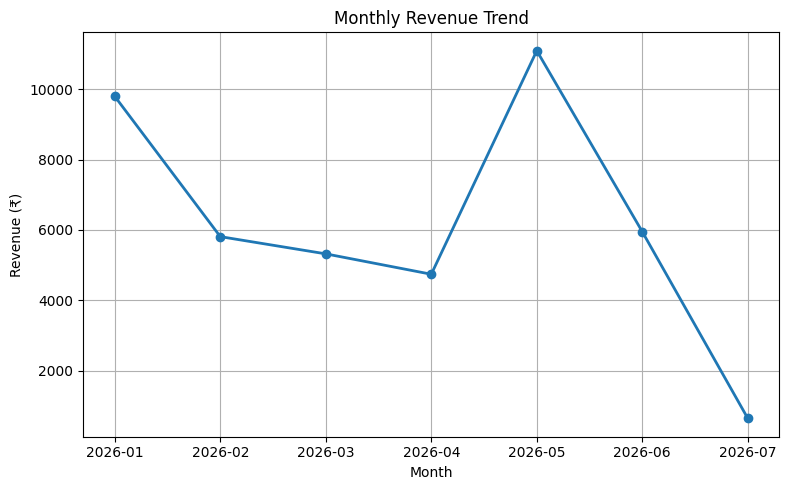

In [9]:
# Plot Monthly Sales

plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalAmount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Daily Sales Plot

daily_sales = (
    orders.groupby(
        orders["OrderDate"].dt.date
    )["TotalAmount"]
    .sum()
    .reset_index()
)

daily_sales.head()

,OrderDate,TotalAmount
0,2026-01-07,1860.0
1,2026-01-10,960.0
2,2026-01-11,1620.0
3,2026-01-13,2600.0
4,2026-01-25,1420.0


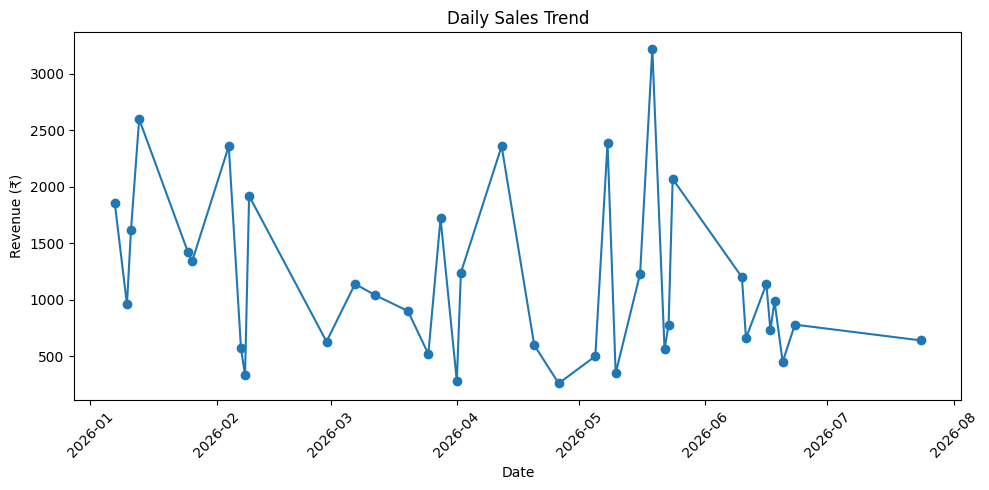

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    daily_sales["OrderDate"],
    daily_sales["TotalAmount"],
    marker="o"
)

plt.title("Daily Sales Trend")

plt.xlabel("Date")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# Revenue by Payment

payment_sales = payments.merge(
    orders,
    on="OrderID"
)

payment_sales.head()

,PaymentID,OrderID,PaymentMethod,PaymentStatus,PaymentDate,CustomerID,EmployeeID,TableID,OrderDate,TotalAmount,Status,YearMonth
0,1,1,UPI,Paid,2026-02-08 14:47:00,4,3,5,2026-02-08 14:47:00,330.0,Completed,2026-02
1,2,2,Cash,Paid,2026-01-07 15:32:00,14,3,1,2026-01-07 15:32:00,1860.0,Completed,2026-01
2,3,3,Cash,Paid,2026-01-25 14:44:00,15,9,5,2026-01-25 14:44:00,1090.0,Completed,2026-01
3,4,4,Card,Paid,2026-03-20 16:51:00,13,3,6,2026-03-20 16:51:00,900.0,Completed,2026-03
4,5,5,Cash,Paid,2026-06-20 17:36:00,3,9,5,2026-06-20 17:36:00,450.0,Completed,2026-06


In [13]:
payment_summary = (
    payment_sales.groupby("PaymentMethod")["TotalAmount"]
    .sum()
)

payment_summary

PaymentMethod
Card    13050.0
Cash    13550.0
UPI     14320.0
Name: TotalAmount, dtype: float64

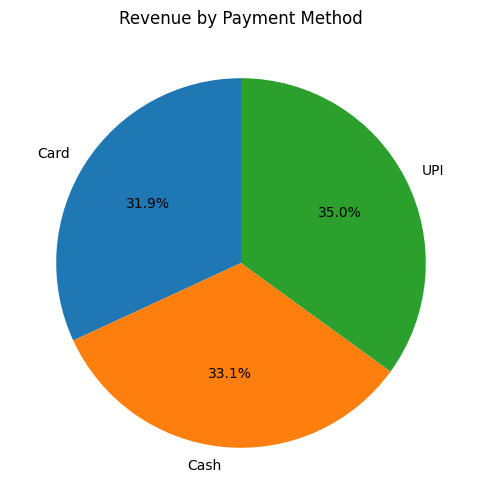

In [14]:
plt.figure(figsize=(6,6))

plt.pie(
    payment_summary,
    labels=payment_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue by Payment Method")

plt.show()

In [15]:
# Revenue by Category

category_sales = (
    order_details
    .merge(menu, on="ItemID")
    .merge(categories, on="CategoryID")
)

category_sales.head()

,DetailID,OrderID,ItemID,Quantity,Subtotal,ItemName,CategoryID,Price,Availability,CategoryName
0,1,1,22,3,180.0,Pepsi,4,60.0,Available,Beverage
1,2,1,24,1,150.0,Cold Coffee,4,150.0,Available,Beverage
2,3,2,1,3,540.0,Spring Rolls,1,180.0,Available,Starter
3,4,2,18,3,300.0,Gulab Jamun,3,100.0,Available,Dessert
4,5,2,7,3,840.0,Dal Makhani,2,300.0,Available,Main Course


In [16]:
category_revenue = (
    category_sales
    .groupby("CategoryName")["Subtotal"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

CategoryName
Main Course    21680.0
Starter         8740.0
Beverage        6860.0
Dessert         6080.0
Name: Subtotal, dtype: float64

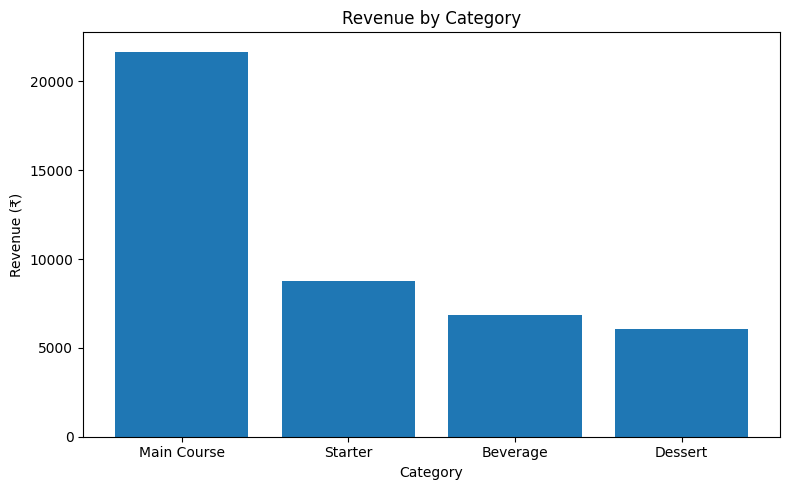

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue (₹)")

plt.tight_layout()

plt.show()

In [18]:
# Top Selling Items

top_items = (
    category_sales
    .groupby("ItemName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_items

ItemName
Dal Makhani        20
Gulab Jamun        17
Spring Rolls       17
Pepsi              15
French Fries       14
Hakka Noodles      12
Chicken Biryani    12
Garlic Bread       11
Brownie            10
Cold Coffee        10
Name: Quantity, dtype: int64

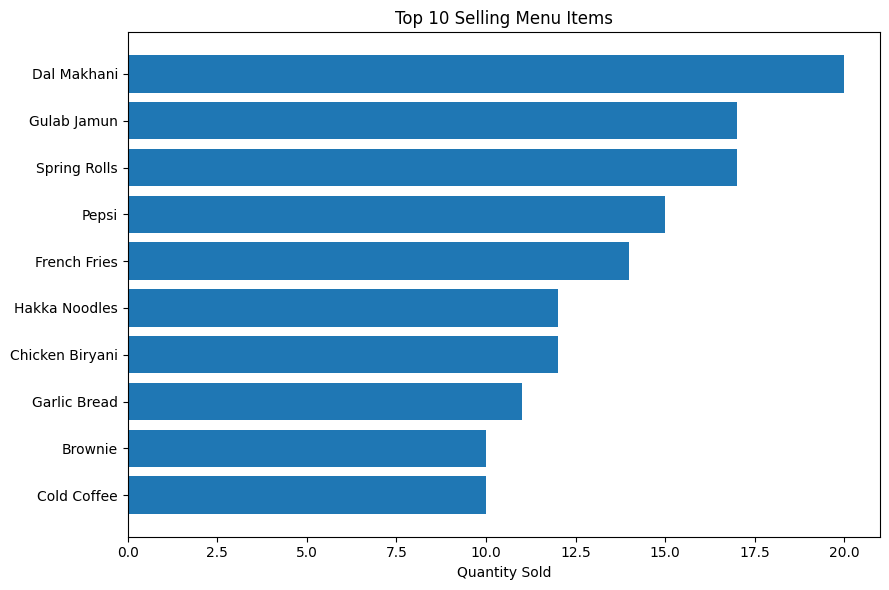

In [19]:
plt.figure(figsize=(9,6))

plt.barh(
    top_items.index,
    top_items.values
)

plt.title("Top 10 Selling Menu Items")

plt.xlabel("Quantity Sold")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [20]:
# Top Customers

customer_sales = (
    orders
    .merge(customers, on="CustomerID")
)

top_customers = (
    customer_sales
    .groupby("CustomerName")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerName
Ritika Jain      4240.0
Rohan Singh      3940.0
Neha Sharma      3680.0
Aman Patel       3610.0
Ishita Tiwari    3370.0
Sneha Singh      3200.0
Priya Gupta      2960.0
Mohit Jain       2710.0
Rahul Gupta      2700.0
Ananya Verma     2610.0
Name: TotalAmount, dtype: float64

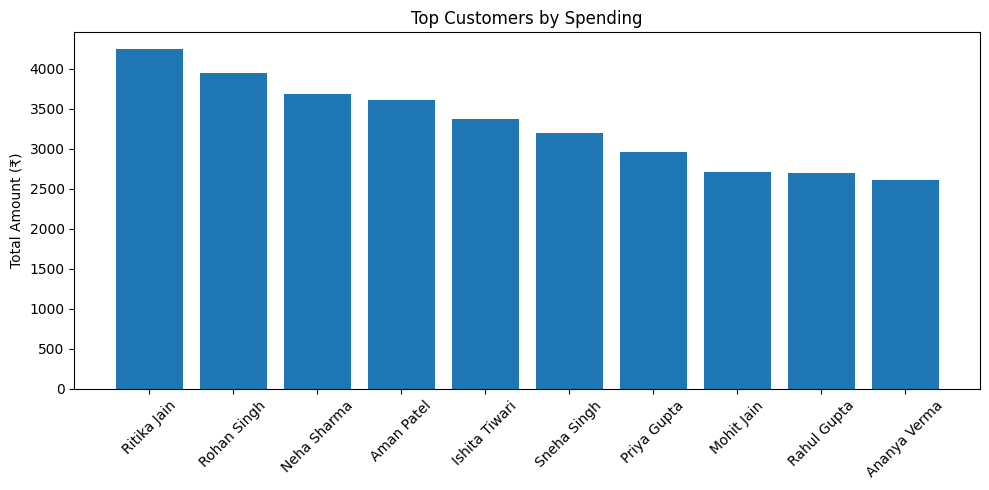

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    top_customers.index,
    top_customers.values
)

plt.title("Top Customers by Spending")

plt.xticks(rotation=45)

plt.ylabel("Total Amount (₹)")

plt.tight_layout()

plt.show()

In [22]:
# peak ordering hrs
orders["Hour"] = orders["OrderDate"].dt.hour

hourly_orders = (
    orders.groupby("Hour")["OrderID"]
    .count()
    .reset_index(name="TotalOrders")
)

hourly_orders

,Hour,TotalOrders
0,12,3
1,13,6
2,14,5
3,15,6
4,16,6
5,17,4
6,18,4
7,19,1
8,20,3
9,21,3


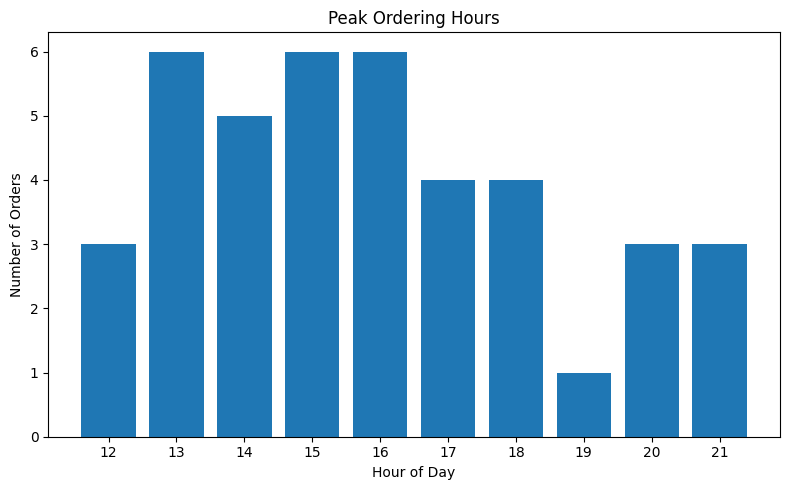

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    hourly_orders["Hour"],
    hourly_orders["TotalOrders"]
)

plt.title("Peak Ordering Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(hourly_orders["Hour"])

plt.tight_layout()
plt.show()

In [24]:
# order status distribution
status_summary = (
    orders["Status"]
    .value_counts()
)

status_summary

Status
Completed    40
Pending       1
Name: count, dtype: int64

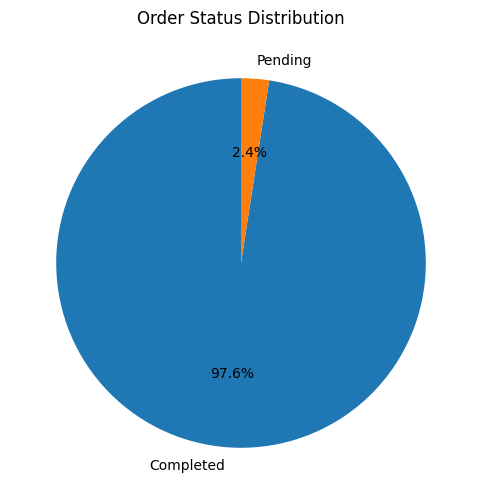

In [25]:
plt.figure(figsize=(6,6))

plt.pie(
    status_summary,
    labels=status_summary.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Order Status Distribution")

plt.show()

In [27]:
# Employees Performance
employee_orders = (
    orders
    .merge(employees, on="EmployeeID")
)

employee_summary = (
    employee_orders
    .groupby("EmployeeName")["OrderID"]
    .count()
    .sort_values(ascending=False)
)

employee_summary

EmployeeName
Amit Kumar    19
Vikas Jain    12
Neha Verma    10
Name: OrderID, dtype: int64

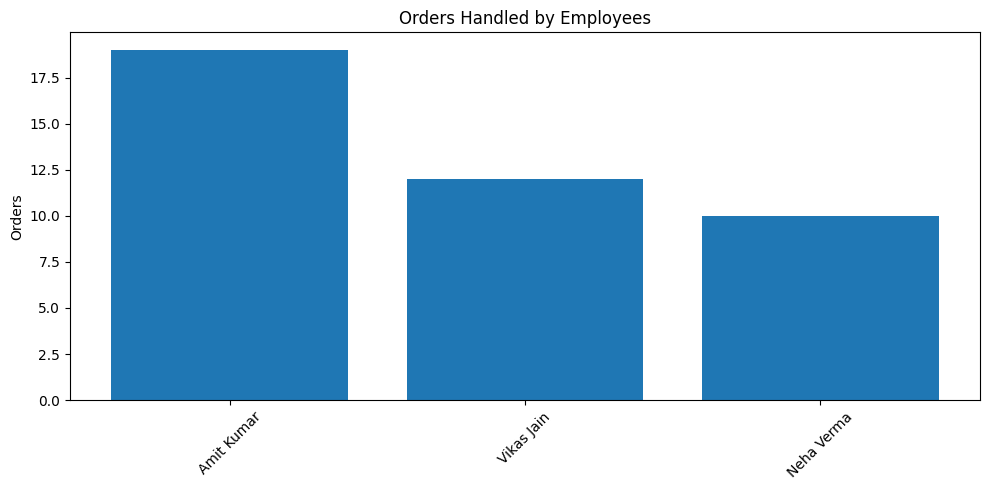

In [28]:
plt.figure(figsize=(10,5))

plt.bar(
    employee_summary.index,
    employee_summary.values
)

plt.xticks(rotation=45)

plt.title("Orders Handled by Employees")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [ ]:
# customer spending
customer_spending = (
    orders
    .groupby("CustomerID")["TotalAmount"]
    .sum()
)

customer_spending.head()

CustomerID
1    1180.0
2    3370.0
3    3940.0
4    2960.0
5     330.0
Name: TotalAmount, dtype: float64

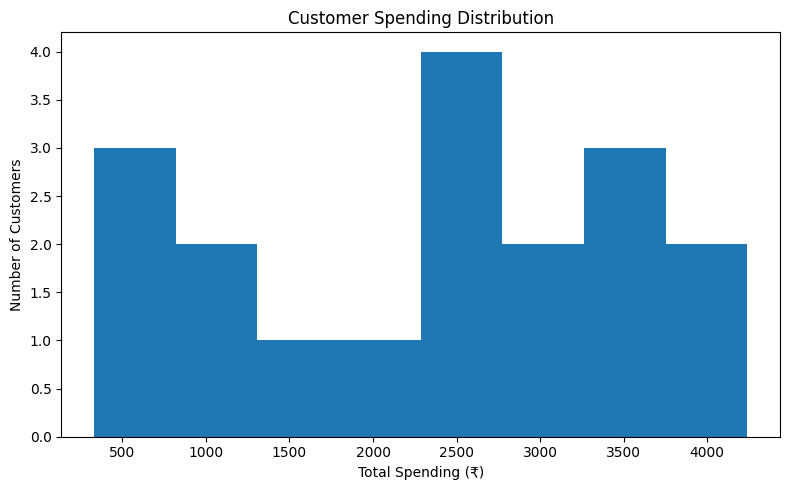

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    customer_spending,
    bins=8
)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending (₹)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

In [31]:
# average spending
average_customer_spending = (
    orders
    .merge(customers, on="CustomerID")
    .groupby("CustomerName")["TotalAmount"]
    .mean()
    .sort_values(ascending=False)
)

average_customer_spending.head(10)

CustomerName
Simran Kaur      2600.000000
Ritika Jain      1413.333333
Mohit Jain       1355.000000
Rahul Gupta      1350.000000
Rohan Singh      1313.333333
Neha Sharma      1226.666667
Aman Patel       1203.333333
Deepak Kumar     1140.000000
Ishita Tiwari    1123.333333
Arjun Kapoor     1090.000000
Name: TotalAmount, dtype: float64

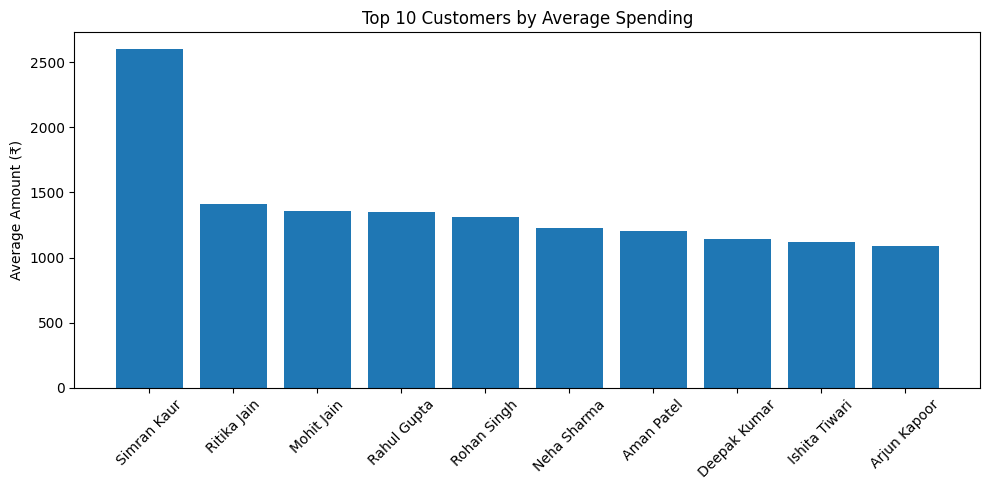

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    average_customer_spending.head(10).index,
    average_customer_spending.head(10).values
)

plt.xticks(rotation=45)

plt.title("Top 10 Customers by Average Spending")

plt.ylabel("Average Amount (₹)")

plt.tight_layout()

plt.show()

In [ ]:
# KPI Summary
kpi = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Total Employees",
        "Total Menu Items"
    ],
    "Value": [
        orders["TotalAmount"].sum(),
        len(orders),
        len(customers),
        round(orders["TotalAmount"].mean(), 2),
        len(employees),
        len(menu)
    ]
})

kpi

,Metric,Value
0,Total Revenue,43360.00
1,Total Orders,41.00
2,Total Customers,20.00
3,Average Order Value,1057.56
4,Total Employees,10.00
5,Total Menu Items,30.00
